# **SVM NOTEBOOK**

In [12]:
# Import 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    classification_report, 
    confusion_matrix, 
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score, 
    roc_auc_score, 
    roc_curve
)

sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')

In [13]:
# Preprocesser-functions
def reshape_zones(df: pd.DataFrame) -> pd.DataFrame:
    zone_dfs = []
    for zone in ["se1", "se2", "se3", "se4"]:
        zone_df = df[
            [
                "timestamp",
                "timestamp_local",
                f"temp_{zone}_c",
                f"wind_{zone}_kmh",
                f"rain_{zone}_mm",
                f"price_{zone}_eur_mwh",
            ]
        ].copy()

        zone_df = zone_df.rename(
            columns={
                f"temp_{zone}_c": "temperature_c",
                f"wind_{zone}_kmh": "wind_speed_kmh",
                f"rain_{zone}_mm": "rain_mm",
                f"price_{zone}_eur_mwh": "spot_price_eur_mwh",
            }
        )
        zone_df["zone"] = zone.upper()
        zone_dfs.append(zone_df)

    return pd.concat(zone_dfs, ignore_index=True)


def clean_data(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True)
    df["timestamp_local"] = pd.to_datetime(df["timestamp_local"], utc=True).dt.tz_convert("Europe/Stockholm")
    df = df.sort_values(["zone", "timestamp"]).reset_index(drop=True)
    df = df.drop_duplicates(subset=["zone", "timestamp"], keep="first")
    return df


def add_time_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["hour"] = df["timestamp_local"].dt.hour
    df["day_of_week"] = df["timestamp_local"].dt.dayofweek
    df["month"] = df["timestamp_local"].dt.month
    df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)
    return df


def add_lag_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df = df.sort_values(["zone", "timestamp"]).reset_index(drop=True)
    df["price_lag_24"] = df.groupby("zone")["spot_price_eur_mwh"].shift(24)
    df["price_lag_48"] = df.groupby("zone")["spot_price_eur_mwh"].shift(48)
    df["price_lag_168"] = df.groupby("zone")["spot_price_eur_mwh"].shift(168)
    return df


def prepare_data(df: pd.DataFrame, include_lags: bool = True) -> pd.DataFrame:
    df = reshape_zones(df)
    df = clean_data(df)
    df = add_time_features(df)
    if include_lags:
        df = add_lag_features(df)
    return df

In [15]:
# Read data and run pipeline
raw_df = pd.read_csv('../dataset/all_zones_complete_2025.csv')
df_processed = prepare_data(raw_df, include_lags=True)
df_processed = df_processed.dropna().reset_index(drop=True)

print(f"Bearbetad data form (alla zoner): {df_processed.shape}")
df_processed.head(3)

Bearbetad data form (alla zoner): (34368, 14)


,timestamp,timestamp_local,temperature_c,wind_speed_kmh,rain_mm,spot_price_eur_mwh,zone,hour,day_of_week,month,is_weekend,price_lag_24,price_lag_48,price_lag_168
0,2025-01-08 00:00:00+00:00,2025-01-08 01:00:00+01:00,-10.6,29.0,0.0,3.94,SE1,1,2,1,0,6.75,20.04,3.97
1,2025-01-08 01:00:00+00:00,2025-01-08 02:00:00+01:00,-10.0,26.5,0.0,4.50,SE1,2,2,1,0,5.70,17.25,3.82
2,2025-01-08 02:00:00+00:00,2025-01-08 03:00:00+01:00,-9.3,27.2,0.0,4.46,SE1,3,2,1,0,4.97,15.48,3.49


In [16]:
# Create target-variabel on all zones at same time
HOURS_TO_SELECT = 6  # De 6 billigaste timmarna per dygn och zon

# Skapa datumkolumn för gruppering
df_processed['date'] = df_processed['timestamp_local'].dt.date

# Beräkna pris-rank per zon och dygn
df_processed['price_rank'] = df_processed.groupby(['zone', 'date'])['spot_price_eur_mwh'].rank(method='min', ascending=True)
df_processed['optimal_timme'] = (df_processed['price_rank'] <= HOURS_TO_SELECT).astype(int)

# One-hot-encode zoner så att modellen vet vilken elpriszon som hanteras
df_processed = pd.get_dummies(df_processed, columns=['zone'], drop_first=False)

print("Total fördelning av målvariabeln för samtliga zoner:")
print(df_processed['optimal_timme'].value_counts())

Total fördelning av målvariabeln för samtliga zoner:
optimal_timme
0    25710
1     8658
Name: count, dtype: int64


In [17]:
# Choose feature and split in Train / Val / Test
# Inkludera de one-hot-kodade zonkolumnerna bland features
feature_cols = [
    'temperature_c', 'wind_speed_kmh', 'rain_mm', 
    'hour', 'day_of_week', 'month', 'is_weekend',
    'price_lag_24', 'price_lag_48', 'price_lag_168',
    'zone_SE1', 'zone_SE2', 'zone_SE3', 'zone_SE4'
]

X = df_processed[feature_cols]
y = df_processed['optimal_timme']

# 70% Train, 15% Validation, 15% Test (stratifierat)
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.15, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.1764, random_state=42, stratify=y_train_val)

print(f"Träningsset: {X_train.shape[0]} rader")
print(f"Valideringsset: {X_val.shape[0]} rader")
print(f"Testset: {X_test.shape[0]} rader")

Träningsset: 24059 rader
Valideringsset: 5153 rader
Testset: 5156 rader


In [18]:
# Scaling with StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [19]:
# Hyperparam-optimization with GridSearchCV
param_grid = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 0.1],
    'kernel': ['rbf']
}

svm = SVC(class_weight='balanced', probability=True, random_state=42)

grid_search = GridSearchCV(
    estimator=svm,
    param_grid=param_grid,
    scoring='f1',
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_scaled, y_train)

print("\nBästa parametrar:")
print(grid_search.best_params_)

best_model = grid_search.best_estimator_

Fitting 3 folds for each of 6 candidates, totalling 18 fits

Bästa parametrar:
{'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}


In [20]:
# Evaluation on model
def evaluate_model(model, X_data, y_data, dataset_name="Test"):
    y_pred = model.predict(X_data)
    y_prob = model.predict_proba(X_data)[:, 1]
    
    print(f"--- Utvärdering på {dataset_name} ---")
    print(f"Accuracy:  {accuracy_score(y_data, y_pred):.4f}")
    print(f"Precision: {precision_score(y_data, y_pred):.4f}")
    print(f"Recall:    {recall_score(y_data, y_pred):.4f}")
    print(f"F1-score:  {f1_score(y_data, y_pred):.4f}")
    print(f"ROC-AUC:   {roc_auc_score(y_data, y_prob):.4f}\n")
    
    print("Classification Report:")
    print(classification_report(y_data, y_pred))

evaluate_model(best_model, X_test_scaled, y_test, dataset_name="Testset")

--- Utvärdering på Testset ---
Accuracy:  0.7853
Precision: 0.5511
Recall:    0.7968
F1-score:  0.6516
ROC-AUC:   0.8630

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.78      0.84      3857
           1       0.55      0.80      0.65      1299

    accuracy                           0.79      5156
   macro avg       0.74      0.79      0.75      5156
weighted avg       0.83      0.79      0.80      5156



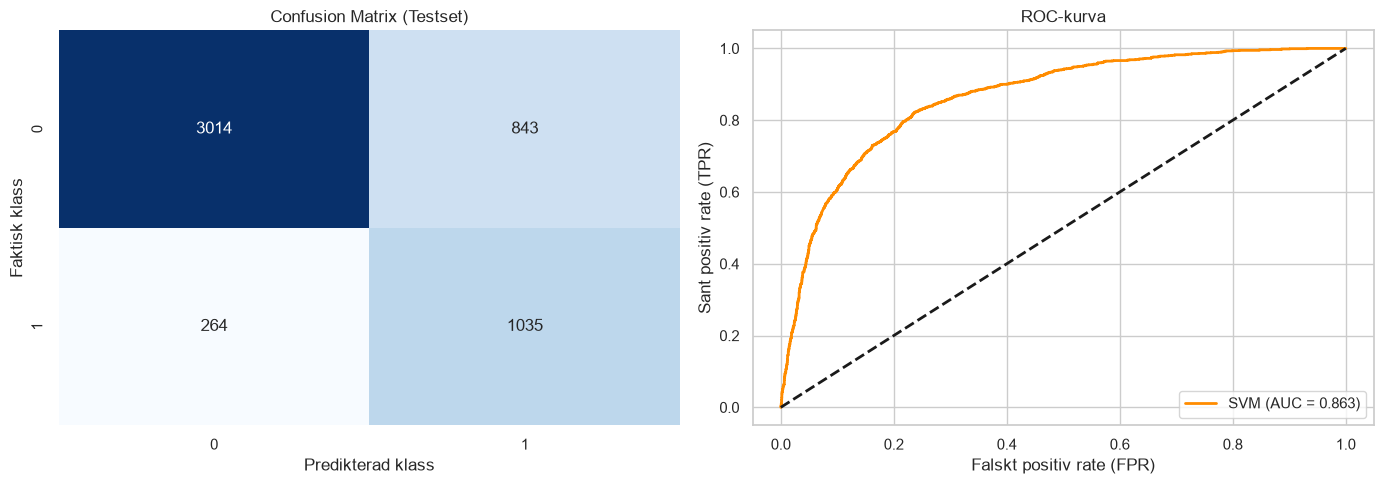

In [21]:
# Visualization (Confusion Matrix & ROC-curv)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, best_model.predict(X_test_scaled))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False)
axes[0].set_title('Confusion Matrix (Testset)')
axes[0].set_xlabel('Predikterad klass')
axes[0].set_ylabel('Faktisk klass')

# ROC-kurva
y_prob_test = best_model.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob_test)
auc_val = roc_auc_score(y_test, y_prob_test)
axes[1].plot(fpr, tpr, label=f'SVM (AUC = {auc_val:.3f})', color='darkorange', lw=2)
axes[1].plot([0, 1], [0, 1], 'k--', lw=2)
axes[1].set_title('ROC-kurva')
axes[1].set_xlabel('Falskt positiv rate (FPR)')
axes[1].set_ylabel('Sant positiv rate (TPR)')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

In [23]:
# Beräkna prediktioner för testsetet först om de inte finns
y_pred_test = best_model.predict(X_test_scaled)

# Skapa en utvärderings-DataFrame för testsetet för att simulera prisskillnaden
df_test_eval = df_processed.loc[X_test.index].copy()
df_test_eval['predicted_optimal'] = y_pred_test

# 1. Genomsnittspris när modellen säger "optimal" (1)
model_avg_price = df_test_eval[df_test_eval['predicted_optimal'] == 1]['spot_price_eur_mwh'].mean()

# 2. Genomsnittspris för de faktiskt billigaste timmarna (Facit / Ground Truth optimal = 1)
actual_best_avg_price = df_test_eval[df_test_eval['optimal_timme'] == 1]['spot_price_eur_mwh'].mean()

# 3. Dygnsmedelpris totalt (Baseline / Slumpmässig förbrukning)
total_avg_price = df_test_eval['spot_price_eur_mwh'].mean()

# 4. Genomsnittspris för de dyraste timmarna (Worst case)
worst_avg_price = df_test_eval[df_test_eval['optimal_timme'] == 0]['spot_price_eur_mwh'].mean()

print(f"--- Affärsmässig Prissimulering (Testset) ---")
print(f"Modellens utvalda snittpris:  {model_avg_price:.2f} EUR/MWh")
print(f"Teoretiskt bästa snittpris:    {actual_best_avg_price:.2f} EUR/MWh")
print(f"Totala dygnsmedelpriset:      {total_avg_price:.2f} EUR/MWh")
print(f"\nModellen sparar ca {total_avg_price - model_avg_price:.2f} EUR/MWh i snitt jämfört med att inte optimera alls!")

--- Affärsmässig Prissimulering (Testset) ---
Modellens utvalda snittpris:  18.91 EUR/MWh
Teoretiskt bästa snittpris:    14.42 EUR/MWh
Totala dygnsmedelpriset:      35.21 EUR/MWh

Modellen sparar ca 16.30 EUR/MWh i snitt jämfört med att inte optimera alls!


In [24]:
# Spara modell och scaler efter godkänd simulering
import joblib
import os

os.makedirs('models/saved_models', exist_ok=True)

joblib.dump(best_model, 'models/saved_models/svm_optimal_classifier.joblib')
joblib.dump(scaler, 'models/saved_models/scaler.joblib')

print("Modell och scaler har sparats framgångsrikt i 'models/saved_models/'!")

Modell och scaler har sparats framgångsrikt i 'models/saved_models/'!


In [25]:
import json

feature_cols = [
    'temperature_c', 'wind_speed_kmh', 'rain_mm', 
    'hour', 'day_of_week', 'month', 'is_weekend',
    'price_lag_24', 'price_lag_48', 'price_lag_168',
    'zone_SE1', 'zone_SE2', 'zone_SE3', 'zone_SE4'
]

with open('models/saved_models/feature_cols.json', 'w') as f:
    json.dump(feature_cols, f)